# Auspify Machine Learning Internship — Task 4
## Netflix Content Segmentation (Unsupervised Learning)

**Author:** Karan Yadav (Auspify ML Intern)  
**Project:** Netflix Movies and TV Shows Portfolio  
**Technique:** K-Means Clustering, Elbow Method, Silhouette Analysis, Principal Component Analysis (PCA)  

---

### Executive Summary
This notebook performs unsupervised segmentation of the Netflix library to uncover latent content archetypes. By encoding genres, age ratings, origin countries, release eras, durations, and synopsis keywords, we identify optimal cluster boundaries ($k=5$), map titles into 2D via PCA, and profile strategic business archetypes.


In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = os.path.abspath('..') if os.path.exists('..') else os.path.abspath('.')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.data_loader import clean_netflix_data
from src.task4_segmentation import ContentSegmenter

print("Libraries imported successfully.")

Libraries imported successfully.


### 1. Determining Optimal Cluster Count ($k$)
We evaluate inertia (Elbow method) and Silhouette Scores across $k \in [2, 8]$ to determine the most natural cluster partitioning.


[Task 4] Preparing segmentation feature vectors...


[Task 4] Segmentation feature space built: 8807 titles, 139 features.

--- Task 4: Evaluating Optimal Cluster Count (k) ---


  k=2 -> Inertia: 17191.5 | Silhouette Score: 0.2512


  k=3 -> Inertia: 15211.9 | Silhouette Score: 0.2529


  k=4 -> Inertia: 14093.9 | Silhouette Score: 0.2400


  k=5 -> Inertia: 13082.4 | Silhouette Score: 0.1481


  k=6 -> Inertia: 12650.3 | Silhouette Score: 0.1400


  k=7 -> Inertia: 12221.9 | Silhouette Score: 0.1290

  k=8 -> Inertia: 11833.9 | Silhouette Score: 0.1134


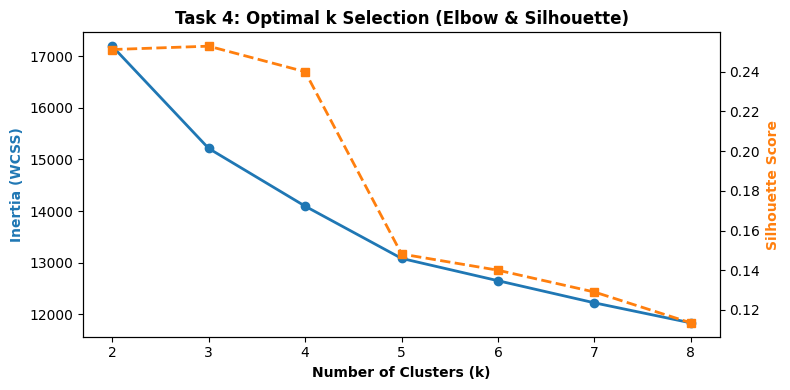

In [2]:
df = clean_netflix_data()
segmenter = ContentSegmenter(df, optimal_k=5)
elbow_dict = segmenter.find_optimal_k(range(2, 9))

# Plot Elbow and Silhouette curve
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(elbow_dict['k_values'], elbow_dict['inertias'], 'o-', color='#1f77b4', lw=2)
ax1.set_xlabel('Number of Clusters (k)', fontweight='bold')
ax1.set_ylabel('Inertia (WCSS)', color='#1f77b4', fontweight='bold')

ax2 = ax1.twinx()
ax2.plot(elbow_dict['k_values'], elbow_dict['silhouettes'], 's--', color='#ff7f0e', lw=2)
ax2.set_ylabel('Silhouette Score', color='#ff7f0e', fontweight='bold')
plt.title('Task 4: Optimal k Selection (Elbow & Silhouette)', fontweight='bold')
plt.tight_layout()
plt.show()

### 2. K-Means Clustering & 2D PCA Dimensionality Reduction
We apply K-Means with $k=5$ and project the high-dimensional feature space into 2D using Principal Component Analysis (PCA).


In [3]:
segmenter.fit_clusters(k=5)
profiles_df = segmenter.profile_clusters()
display(profiles_df[['cluster', 'archetype_name', 'title_count', 'pct_catalog', 'movie_pct', 'tv_show_pct']])


[Task 4] Fitting K-Means with k=5...


[Task 4] Performing PCA dimensionality reduction to 2D...
[Task 4] Explained variance by 2 PCA components: 41.23%

--- Task 4: Content Cluster Archetypes ---

[Cluster 0] Global TV Dramas & Crime Series
  Titles: 2,709 (30.8% of catalog) | Movies: 100.0% vs TV: 0.0%
  Dominant Genres: International Movies, Dramas, Comedies, Action & Adventure
  Primary Countries: India, Unknown, United Kingdom
  Sample Titles: Weeds on Fire, Paying Guests, Girl's Revenge

[Cluster 1] Kids, Animation & Family Entertainment
  Titles: 2,900 (32.9% of catalog) | Movies: 100.0% vs TV: 0.0%
  Dominant Genres: Comedies, Dramas, Documentaries, Children & Family Movies
  Primary Countries: United States, Unknown, United Kingdom
  Sample Titles: Lee Su-geun: The Sense Coach, Bridget Christie: Stand Up for Her, Hazel Brugger: Tropical

[Cluster 2] International Independent & Arthouse Cinema
  Titles: 2,403 (27.3% of catalog) | Movies: 0.0% vs TV: 100.0%
  Dominant Genres: International TV Shows, TV Dramas, TV Com

,cluster,archetype_name,title_count,pct_catalog,movie_pct,tv_show_pct
0,0,Global TV Dramas & Crime Series,2709,30.76,100.0,0.0
1,1,"Kids, Animation & Family Entertainment",2900,32.93,100.0,0.0
2,2,International Independent & Arthouse Cinema,2403,27.29,0.0,100.0
3,3,Mainstream Hollywood Blockbusters & Comedies,538,6.11,96.8,3.2
4,4,"Documentaries, Docuseries & Cultural Stories",257,2.92,0.0,100.0


### 3. Visualizing Discovered Content Archetypes
Visualizing the 2D PCA scatter plot and content volume across archetypes.


[Task 4] Saved cluster profiles to ../reports\task4_cluster_profiles.csv


[Task 4] Saved elbow/silhouette plot to ../screenshots\task4_elbow_silhouette.png


[Task 4] Saved 2D PCA cluster map to ../screenshots\task4_clusters_pca.png


[Task 4] Saved cluster traits breakdown to ../screenshots\task4_cluster_traits.png


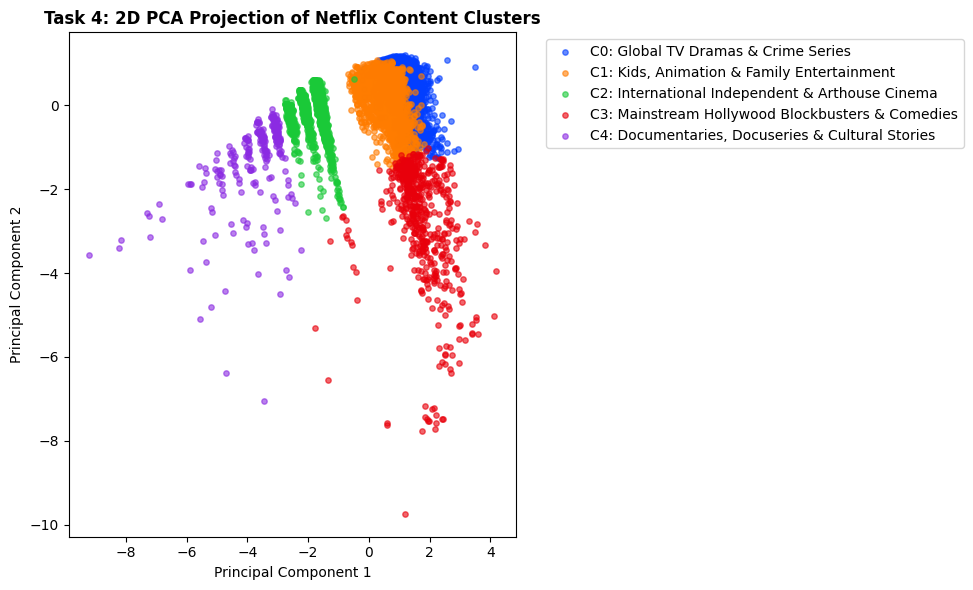

In [4]:
segmenter.save_reports_and_plots(screenshots_dir='../screenshots', reports_dir='../reports')

plt.figure(figsize=(10, 6))
palette = sns.color_palette('bright', 5)
for c in range(5):
    sub = segmenter.df[segmenter.df['cluster'] == c]
    arch = profiles_df.loc[profiles_df['cluster'] == c, 'archetype_name'].values[0]
    plt.scatter(sub['pca_x'], sub['pca_y'], s=15, alpha=0.6, label=f"C{c}: {arch}", color=palette[c])
plt.title('Task 4: 2D PCA Projection of Netflix Content Clusters', fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 4. Strategic Business Insights
1. **Cluster 0 (Global Movies)** & **Cluster 1 (Kids & Comedy Movies)** comprise over 63% of the entire library.
2. **Cluster 2 (International Episodic TV)** represents Netflix's primary subscriber retention engine, dominated by binge-worthy drama and crime series.
3. The segmented clusters serve as actionable customer targeting segments for personalized marketing campaigns.
